In [2]:
import pandas as pd
# Cargar el dataset housing.csv en un DataFrame de pandas llamado datos
datos = pd.read_csv("housing.csv")

importamos housing.csv hacia un dataframe

In [3]:
# Mostrar las primeras 5 filas del DataFrame para visualizar los primeros datos
datos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<Axes: xlabel='latitude', ylabel='longitude'>

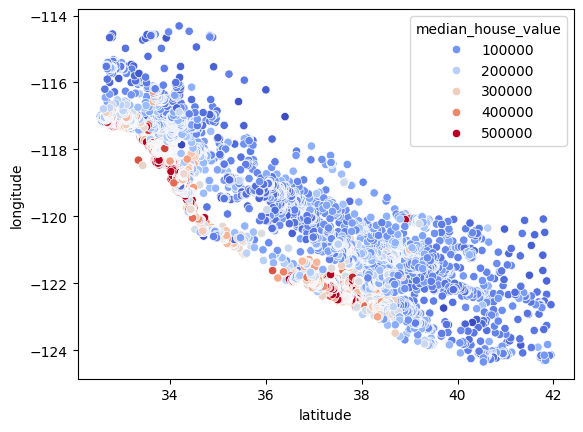

In [4]:
import seaborn as sb
# Crear un scatterplot para visualizar la latitud y longitud de las casas
# El color de los puntos representa el valor medio de las casas (median_house_value)
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_house_value",
               palette="coolwarm")

creamos un scatterplot en donde vemos la latitud y la longitud en la que se ubican las casas y cual es el valor medio de las casas

<Axes: xlabel='latitude', ylabel='longitude'>

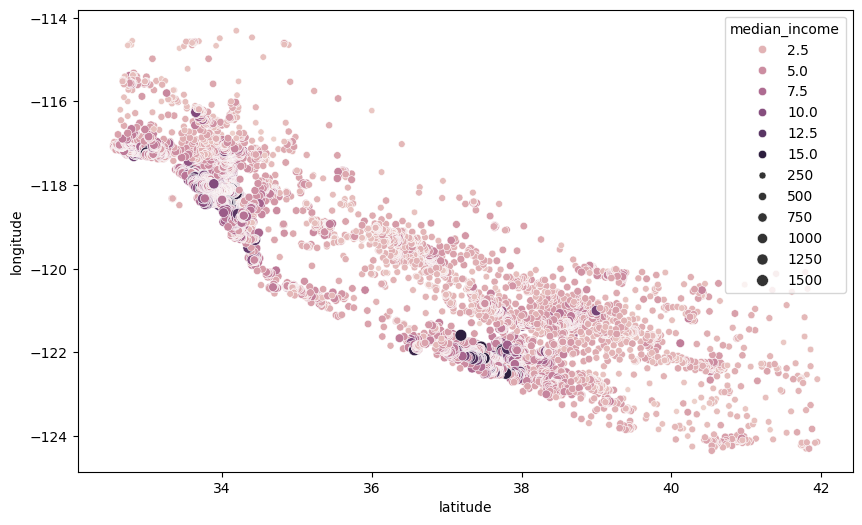

In [20]:
import seaborn as sb
import matplotlib.pyplot as plt
# Crear un scatterplot para visualizar la latitud y longitud de las casas
# El color de los puntos representa el ingreso medio (median_income)
plt.figure(figsize=(10, 6))
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_income",
               size=datos["median_income"]*100) # Scale the median income for point size

In [6]:
# Seleccionar las columnas "latitude", "longitude" y "median_income" del DataFrame datos
datos.loc[:, ["latitude", "longitude", "median_income"]]

,latitude,longitude,median_income
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462
...,...,...,...
20635,39.48,-121.09,1.5603
20636,39.49,-121.21,2.5568
20637,39.43,-121.22,1.7000
20638,39.43,-121.32,1.8672


In [7]:
from sklearn.cluster import KMeans

# Seleccionar las columnas para el clustering
X = datos.loc[:, ["latitude", "longitude", "median_income"]]
# Inicializar el modelo KMeans con 6 clusters
modelo = KMeans(n_clusters=6)
# Entrenar el modelo y obtener las predicciones de los clusters para cada fila
predicciones = modelo.fit_predict(X)

In [8]:
# Mostrar la forma del array de predicciones para verificar la cantidad de asignaciones de cluster
predicciones.shape

(20640,)

In [9]:
# Agregar las predicciones de los clusters como una nueva columna llamada "segmento_economico" al DataFrame X
X["segmento_economico"] = predicciones

In [10]:
# Mostrar el DataFrame X con la nueva columna "segmento_economico"
X

,latitude,longitude,median_income,segmento_economico
0,37.88,-122.23,8.3252,4
1,37.86,-122.22,8.3014,4
2,37.85,-122.24,7.2574,4
3,37.85,-122.25,5.6431,4
4,37.85,-122.25,3.8462,1
...,...,...,...,...
20635,39.48,-121.09,1.5603,1
20636,39.49,-121.21,2.5568,1
20637,39.43,-121.22,1.7000,1
20638,39.43,-121.32,1.8672,1


In [11]:
# Contar la cantidad de filas en cada segmento económico (cluster)
X["segmento_economico"].value_counts()

,count
segmento_economico,
0,6576
1,4878
5,4195
4,2768
2,1677
3,546


<Axes: xlabel='latitude', ylabel='longitude'>

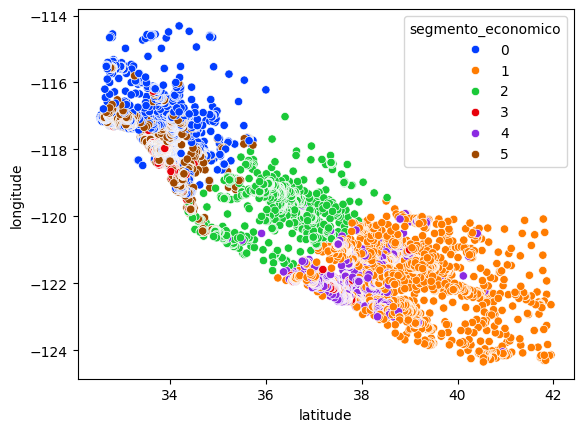

In [12]:
import seaborn as sb
# Crear un scatterplot para visualizar la latitud y longitud de las casas, coloreadas por el segmento económico (cluster)
# Se utiliza la paleta de colores "bright"
sb.scatterplot(x="latitude", y="longitude", data=X, hue="segmento_economico",
               palette="bright")

<Axes: xlabel='segmento_economico', ylabel='count'>

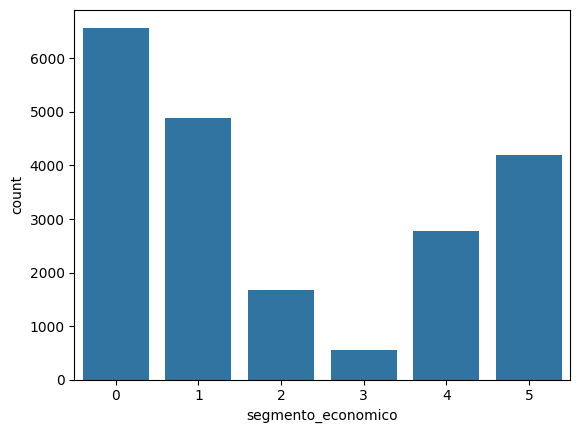

In [13]:
# Crear un gráfico de barras para visualizar la distribución de las casas por segmento económico (cluster)
sb.countplot(x="segmento_economico", data=X)

In [14]:
# Calcular el ingreso medio ("median_income") para cada segmento económico (cluster)
X.groupby(["segmento_economico"])["median_income"].mean()

,median_income
segmento_economico,
0,2.790984
1,2.823116
2,2.660862
3,10.513539
4,5.520247
5,5.311865
